In [1]:
import numpy as np
import re
import matplotlib.pyplot as plt


In [2]:
import pandas as pd
from pathlib import Path

csv_path = "2024_public_lar_csv.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
print("\nHead:")
print(df.head())

/tmp/ipykernel_3336475/3379723330.py:5: DtypeWarning: Columns (0: census_tract, 1: combined_loan_to_value_ratio, 2: interest_rate, 3: rate_spread, 4: total_loan_costs, 5: total_points_and_fees, 6: origination_charges, 7: discount_points, 8: lender_credits, 9: loan_term, 10: prepayment_penalty_term, 11: intro_rate_period, 12: property_value, 13: total_units, 14: multifamily_affordable_units, 15: debt_to_income_ratio, 16: applicant_age, 17: co_applicant_age, 18: applicant_age_above_62, 19: co_applicant_age_above_62) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Shape: (12229298, 99)
Columns:
['activity_year', 'lei', 'derived_msa_md', 'state_code', 'county_code', 'census_tract', 'conforming_loan_limit', 'derived_loan_product_type', 'derived_dwelling_category', 'derived_ethnicity', 'derived_race', 'derived_sex', 'action_taken', 'purchaser_type', 'preapproval', 'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage', 'open_end_line_of_credit', 'business_or_commercial_purpose', 'loan_amount', 'combined_loan_to_value_ratio', 'interest_rate', 'rate_spread', 'hoepa_status', 'total_loan_costs', 'total_points_and_fees', 'origination_charges', 'discount_points', 'lender_credits', 'loan_term', 'prepayment_penalty_term', 'intro_rate_period', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'property_value', 'construction_method', 'occupancy_type', 'manufactured_home_secured_property_type', 'manufactured_home_land_property_interest', 'total_units', 'multifamily_affordable_units', 'income', 'debt_t

In [3]:
print(df.columns)

Index(['activity_year', 'lei', 'derived_msa_md', 'state_code', 'county_code',
       'census_tract', 'conforming_loan_limit', 'derived_loan_product_type',
       'derived_dwelling_category', 'derived_ethnicity', 'derived_race',
       'derived_sex', 'action_taken', 'purchaser_type', 'preapproval',
       'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage',
       'open_end_line_of_credit', 'business_or_commercial_purpose',
       'loan_amount', 'combined_loan_to_value_ratio', 'interest_rate',
       'rate_spread', 'hoepa_status', 'total_loan_costs',
       'total_points_and_fees', 'origination_charges', 'discount_points',
       'lender_credits', 'loan_term', 'prepayment_penalty_term',
       'intro_rate_period', 'negative_amortization', 'interest_only_payment',
       'balloon_payment', 'other_nonamortizing_features', 'property_value',
       'construction_method', 'occupancy_type',
       'manufactured_home_secured_property_type',
       'manufactured_home_land_property_in

In [4]:
df['debt_to_income_ratio'].head(10)

0     50%-60%
1          42
2         NaN
3          47
4    20%-<30%
5         NaN
6          39
7     50%-60%
8          49
9    20%-<30%
Name: debt_to_income_ratio, dtype: object

In [5]:
na_rate = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

na_rate.columns = ['variable', 'na_rate']

print(na_rate.to_string())

                                    variable   na_rate
0                   co_applicant_ethnicity_5  0.999997
1                   co_applicant_ethnicity_4  0.999989
2                      applicant_ethnicity_5  0.999989
3                      applicant_ethnicity_4  0.999961
4                        co_applicant_race_5  0.999927
5                           applicant_race_5  0.999809
6                        co_applicant_race_4  0.999796
7                   co_applicant_ethnicity_3  0.999585
8                           applicant_race_4  0.999429
9                      applicant_ethnicity_3  0.998743
10                           denial_reason_4  0.998706
11                       co_applicant_race_3  0.998572
12                          applicant_race_3  0.995989
13                                     aus_5  0.993409
14                           denial_reason_3  0.992847
15                                     aus_4  0.992360
16                                     aus_3  0.982134
17        

In [6]:
cols_to_keep = na_rate[na_rate['na_rate'] <= 0.35]['variable'].tolist()

df = df[cols_to_keep]


In [7]:
df=df.dropna().reset_index(drop=True)
df.shape

(5787357, 66)

In [8]:
df["debt_to_income_ratio"].head()

0          42
1          47
2    20%-<30%
3          39
4    20%-<30%
Name: debt_to_income_ratio, dtype: object

In [9]:
def dti_to_numeric(x):
    """Convert DTI to approximate numeric value: midpoint for ranges, keep as-is for pure numbers"""
    if pd.isna(x):
        return np.nan
    
    s = str(x).strip()
    if s == "" or s.lower() in ["nan", "na", "n/a", "exempt"]:
        return np.nan

    # Pure numeric value
    try:
        return float(s)
    except:
        pass

    s = s.replace(" ", "")

    # <20%
    m = re.match(r"^<(\d+(?:\.\d+)?)%$", s)
    if m:
        upper = float(m.group(1))
        return upper / 2

    # >60%
    m = re.match(r"^>(\d+(?:\.\d+)?)%$", s)
    if m:
        lower = float(m.group(1))
        return lower + 5

    # 20%-<30%
    m = re.match(r"^(\d+(?:\.\d+)?)%-<(\d+(?:\.\d+)?)%$", s)
    if m:
        a, b = float(m.group(1)), float(m.group(2))
        return (a + b) / 2

    # 50%-60%
    m = re.match(r"^(\d+(?:\.\d+)?)%-(\d+(?:\.\d+)?)%$", s)
    if m:
        a, b = float(m.group(1)), float(m.group(2))
        return (a + b) / 2

    return np.nan


# Generate two columns
df['dti_num'] = df["debt_to_income_ratio"].apply(dti_to_numeric)

# View results
print(df[['dti_num']].head(40))

    dti_num
0      42.0
1      47.0
2      25.0
3      39.0
4      25.0
5      37.0
6      10.0
7      10.0
8      42.0
9      33.0
10     39.0
11     41.0
12     55.0
13     42.0
14     33.0
15     38.0
16     49.0
17     33.0
18     25.0
19     55.0
20     37.0
21     10.0
22     45.0
23     33.0
24     25.0
25     55.0
26     44.0
27     55.0
28     44.0
29     10.0
30     43.0
31     33.0
32     49.0
33     25.0
34     41.0
35     44.0
36     55.0
37     33.0
38     49.0
39     25.0


In [10]:
df = df.drop(columns=["debt_to_income_ratio"])

In [11]:

df.columns

Index(['interest_rate', 'combined_loan_to_value_ratio', 'property_value',
       'income', 'applicant_age_above_62', 'census_tract', 'county_code',
       'state_code', 'loan_term', 'conforming_loan_limit',
       'applicant_ethnicity_1', 'applicant_race_1', 'co_applicant_ethnicity_1',
       'co_applicant_race_1', 'business_or_commercial_purpose',
       'open_end_line_of_credit', 'hoepa_status', 'derived_loan_product_type',
       'activity_year', 'lei', 'derived_msa_md', 'loan_amount',
       'derived_dwelling_category', 'derived_ethnicity', 'derived_race',
       'derived_sex', 'action_taken', 'purchaser_type', 'preapproval',
       'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage',
       'negative_amortization', 'applicant_ethnicity_observed',
       'occupancy_type', 'construction_method',
       'co_applicant_ethnicity_observed', 'total_units', 'balloon_payment',
       'interest_only_payment', 'manufactured_home_land_property_interest',
       'manufactured_home_s

In [12]:
df[["interest_rate",
    "combined_loan_to_value_ratio",
    "property_value",
    "income",
    "loan_term",
    "conforming_loan_limit",
    "loan_amount",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "tract_owner_occupied_units",
    "tract_one_to_four_family_homes",
    "tract_median_age_of_housing_units",
    "dti_num",
    "applicant_age_above_62"]].head()

,interest_rate,combined_loan_to_value_ratio,property_value,income,loan_term,conforming_loan_limit,loan_amount,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units,dti_num,applicant_age_above_62
0,12.59,44.37,695000.0,124.0,360,C,85000,2045,6.26,116200,132.0,834,1455,59,42.0,No
1,9.34,50.55,865000.0,113.0,360,C,125000,5221,7.03,106700,107.0,1600,1891,34,47.0,Yes
2,10.09,22.22,225000.0,34.0,360,C,55000,4692,5.58,81400,112.0,1514,2130,41,25.0,No
3,9.56,63.16,1465000.0,352.0,360,C,455000,3418,25.16,164200,184.0,990,1121,50,39.0,Yes
4,9.49,79.14,875000.0,379.0,360,C,325000,5684,11.98,143700,144.0,1849,1903,26,25.0,No


In [13]:
num_cols = [
    "interest_rate",
    "combined_loan_to_value_ratio",
    "property_value",
    "income",
    "loan_term",
    "loan_amount",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "tract_owner_occupied_units",
    "tract_one_to_four_family_homes",
    "tract_median_age_of_housing_units",
    "dti_num",
    "applicant_age_above_62"
]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

cat_cols = [
    "activity_year", "derived_ethnicity", "derived_race", "derived_sex",
    "loan_type", "loan_purpose", "lien_status", "occupancy_type",
    "construction_method", "action_taken", "derived_loan_product_type",
    "business_or_commercial_purpose", "open_end_line_of_credit",
    "reverse_mortgage", "hoepa_status"
]

for c in cat_cols:
    df[c] = df[c].astype("category")
id_cols = ["census_tract", "county_code", "state_code", "lei", "derived_msa_md"]

for c in id_cols:
    df[c] = df[c].astype(str)
df['total_units'] = pd.to_numeric(df['total_units'], errors='coerce')

In [14]:
print(df.dtypes)

interest_rate                        float64
combined_loan_to_value_ratio         float64
property_value                       float64
income                               float64
applicant_age_above_62               float64
                                      ...   
tract_to_msa_income_percentage       float64
tract_owner_occupied_units             int64
tract_one_to_four_family_homes         int64
tract_median_age_of_housing_units      int64
dti_num                              float64
Length: 66, dtype: object


In [15]:
df["combined_loan_to_value_ratio"].head()

0    44.37
1    50.55
2    22.22
3    63.16
4    79.14
Name: combined_loan_to_value_ratio, dtype: float64

In [16]:
df=df[df["combined_loan_to_value_ratio"]<=100]

In [17]:
df["total_units"].value_counts()

total_units
1    5291146
2      78143
3      14487
4       9423
Name: count, dtype: int64

In [18]:
df["conforming_loan_limit"].value_counts()

conforming_loan_limit
C     5224060
NC     169139
Name: count, dtype: int64

In [19]:
dftest=df[df["total_units"]==1]

In [20]:
dftest.shape

(5291146, 66)

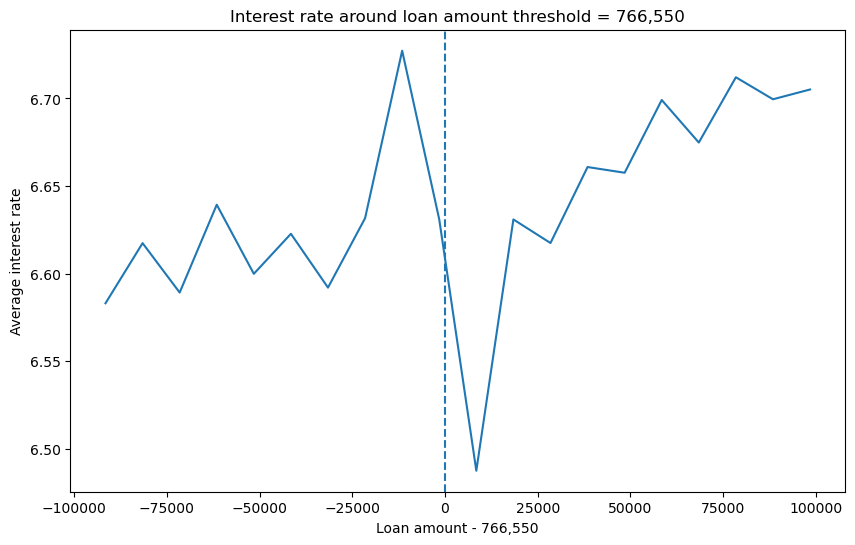

    running_mean  rate_mean      n
0       -91550.0   6.583085  13847
1       -81550.0   6.617401  13711
2       -71550.0   6.589204  11565
3       -61550.0   6.639336  15652
4       -51550.0   6.599897  11229
5       -41550.0   6.622732  13582
6       -31550.0   6.592031  10161
7       -21550.0   6.631626  10638
8       -11550.0   6.727218  15085
9        -1550.0   6.630962  35199
10        8450.0   6.487522   4812
11       18450.0   6.630938   4568
12       28450.0   6.617470   4736
13       38450.0   6.660832   8709
14       48450.0   6.657574   3382
15       58450.0   6.699089   3940
16       68450.0   6.674825   3048
17       78450.0   6.712073   4024
18       88450.0   6.699506   4514
19       98450.0   6.705095   3560


In [21]:
tmp2=dftest.copy()
tmp2["running"] = tmp2["loan_amount"] - 766550
tmp2["above"] = (tmp2["running"] >= 0).astype(int)
h = 100000
plot_df = tmp2[tmp2["running"].between(-h, h)].copy()

# Binning: one bin per $5000
bins = np.arange(-h, h + 5000, 5000)
plot_df["bin"] = pd.cut(plot_df["running"], bins=bins, include_lowest=True)

binned = (
    plot_df.groupby("bin", observed=False)
           .agg(
               running_mean=("running", "mean"),
               rate_mean=("interest_rate", "mean"),
               n=("interest_rate", "size")
           )
           .dropna()
           .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
plt.plot(binned["running_mean"], binned["rate_mean"])
plt.axvline(0, linestyle="--")
plt.xlabel("Loan amount - 766,550")
plt.ylabel("Average interest rate")
plt.title("Interest rate around loan amount threshold = 766,550")
plt.show()

print(binned.head(20))

In [22]:
local = tmp2[tmp2["running"].between(-50000, 50000)].copy()
local["above"] = (local["running"] >= 0).astype(int)

for col in ["income", "property_value", "combined_loan_to_value_ratio", "loan_term"]:
    print("\n", col)
    print(local.groupby("above")[col].agg(["mean", "median", "count"]))


 income
             mean  median  count
above                           
0      327.749412   259.0  84665
1      354.356622   267.0  26207

 property_value
               mean    median  count
above                               
0      1.076891e+06  945000.0  84665
1      1.120964e+06  995000.0  26207

 combined_loan_to_value_ratio
            mean  median  count
above                          
0      77.395847    80.0  84665
1      77.925774    80.0  26207

 loan_term
             mean  median  count
above                           
0      352.344251   360.0  84665
1      354.878925   360.0  26207


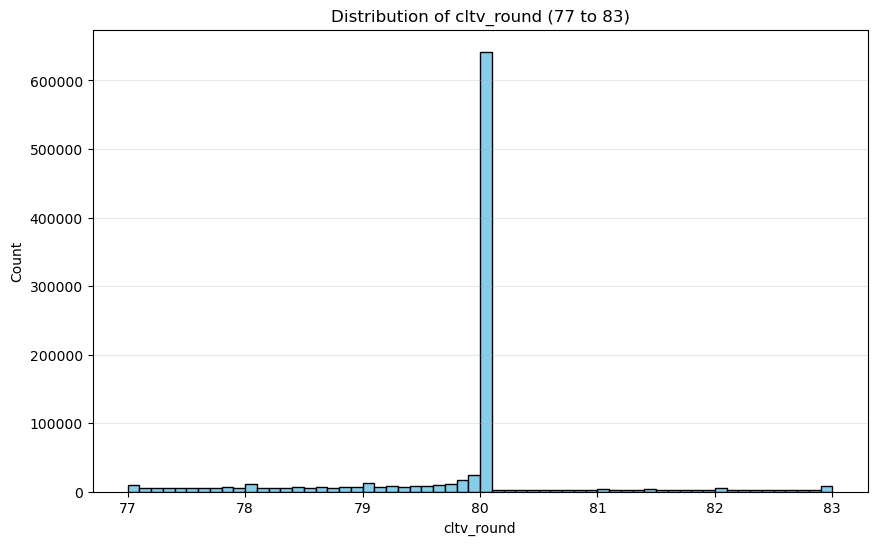

In [23]:
tmp1 = dftest.copy()
tmp1["cltv_round"] = tmp1["combined_loan_to_value_ratio"].round(1)
plot_data = tmp1[(tmp1['cltv_round'] >= 77) & (tmp1['cltv_round'] <= 83)]

plt.figure(figsize=(10, 6))

plt.hist(plot_data['cltv_round'], bins=60, color='skyblue', edgecolor='black')

plt.title('Distribution of cltv_round (77 to 83)')
plt.xlabel('cltv_round')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [24]:
# 1. Ensure income column is numeric (to avoid errors)
tmp1['income'] = pd.to_numeric(tmp1['income'], errors='coerce')

# 2. Calculate mean values
avg_income_above = tmp1.query('cltv_round > 80.1')['income'].mean()
avg_income_below = tmp1.query('cltv_round <= 80.1')['income'].mean()

# 3. Print results
print(f"CLTV > 80.1 average income: {avg_income_above:.2f}")
print(f"CLTV <= 80.1 average income: {avg_income_below:.2f}")

CLTV > 80.1 average income: 135.55
CLTV <= 80.1 average income: 185.04


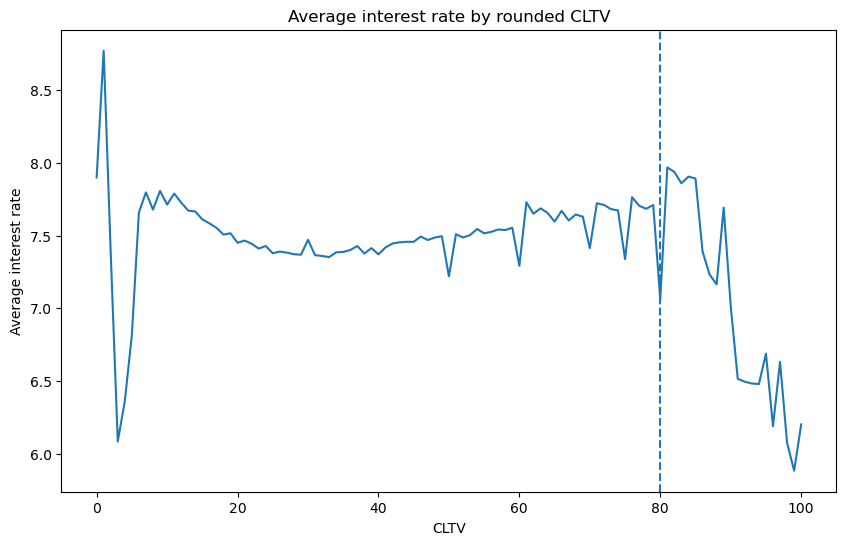

In [25]:
tmp = dftest.copy()
tmp["cltv_round"] = tmp["combined_loan_to_value_ratio"].round(0)

curve_df = (
    tmp.groupby("cltv_round", as_index=False)["interest_rate"]
       .mean()
       .sort_values("cltv_round")
)

plt.figure(figsize=(10, 6))
plt.plot(curve_df["cltv_round"], curve_df["interest_rate"])
plt.axvline(80, linestyle="--")
plt.xlabel("CLTV")
plt.ylabel("Average interest rate")
plt.title("Average interest rate by rounded CLTV")
plt.show()

In [26]:
pmi_proxy = 0.8

dftest["effective_rate"] = dftest["interest_rate"] + np.where(
    dftest["combined_loan_to_value_ratio"] > 80,
    pmi_proxy,
    0
)

In [27]:
dftest["loan_term"].head()

0    360.0
1    360.0
2    360.0
3    360.0
4    360.0
Name: loan_term, dtype: float64

In [28]:


# ========= 3. Set PMI proxy =========
pmi_rate = 0.008   # Annualized 0.8%
dftest["cltv_gt_80"] = (dftest["combined_loan_to_value_ratio"] > 80).astype(int)

# ========= 4. Calculate monthly payment (fixed installment) =========
P = dftest["loan_amount"]
annual_rate = dftest["interest_rate"] / 100
r = annual_rate / 12
n = dftest["loan_term"]

# Handle zero interest rate
dftest["monthly_payment"] = np.where(
    (P.notna()) & (n.notna()) & (n > 0) & (r == 0),
    P / n,
    np.where(
        (P.notna()) & (n.notna()) & (n > 0) & (r != 0),
        P * (r * (1 + r) ** n) / ((1 + r) ** n - 1),
        np.nan
    )
)

# ========= 5. Estimate original property value =========
# CLTV = loan_amount / property_value * 100
# Therefore property_value ≈ loan_amount / (CLTV/100)
dftest["property_value_est"] = np.where(
    dftest["combined_loan_to_value_ratio"] > 0,
    dftest["loan_amount"] / (dftest["combined_loan_to_value_ratio"] / 100),
    np.nan
)

# ========= 6. Calculate monthly PMI amount =========
dftest["pmi_amount_monthly"] = np.where(
    dftest["cltv_gt_80"] == 1,
    dftest["loan_amount"] * pmi_rate / 12,
    0
)

# ========= 7. Calculate PMI duration in months =========
# Use "loan balance drops to 80% of original property value" as PMI cancellation point
def calc_pmi_months(row):
    P = row["loan_amount"]
    annual_rate = row["interest_rate"] / 100 if pd.notna(row["interest_rate"]) else np.nan
    r = annual_rate / 12 if pd.notna(annual_rate) else np.nan
    n = row["loan_term"]
    cltv = row["combined_loan_to_value_ratio"]
    prop_val = row["property_value_est"]
    M = row["monthly_payment"]

    if pd.isna(P) or pd.isna(r) or pd.isna(n) or pd.isna(cltv) or pd.isna(prop_val) or pd.isna(M):
        return np.nan
    if cltv <= 80:
        return 0

    target_balance = 0.80 * prop_val

    # With zero interest rate, balance decreases linearly
    if r == 0:
        monthly_principal = P / n
        months_needed = np.ceil((P - target_balance) / monthly_principal)
        return int(max(0, min(n, months_needed)))

    # Find month-by-month when balance drops to target_balance
    balance = P
    for m in range(1, int(n) + 1):
        interest_part = balance * r
        principal_part = M - interest_part
        balance -= principal_part
        if balance <= target_balance:
            return m

    return int(n)

dftest["pmi_months"] = dftest.apply(calc_pmi_months, axis=1)

# ========= 8. Total PMI, total principal+interest, total repayment =========
dftest["total_pmi_paid"] = dftest["pmi_amount_monthly"] * dftest["pmi_months"]
dftest["total_principal_interest_paid"] = dftest["monthly_payment"] * dftest["loan_term"]
dftest["total_repayment_including_pmi"] = (
    dftest["total_principal_interest_paid"] + dftest["total_pmi_paid"]
)

# ========= 9. View results =========
dftest[[
    "loan_amount",
    "interest_rate",
    "combined_loan_to_value_ratio",
    "loan_term",
    "monthly_payment",
    "pmi_amount_monthly",
    "pmi_months",
    "total_pmi_paid",
    "total_principal_interest_paid",
    "total_repayment_including_pmi"
]].head()

,loan_amount,interest_rate,combined_loan_to_value_ratio,loan_term,monthly_payment,pmi_amount_monthly,pmi_months,total_pmi_paid,total_principal_interest_paid,total_repayment_including_pmi
0,85000,12.59,44.37,360.0,913.109235,0.0,0.0,0.0,3.287193e+05,3.287193e+05
1,125000,9.34,50.55,360.0,1036.506893,0.0,0.0,0.0,3.731425e+05,3.731425e+05
2,55000,10.09,22.22,360.0,486.326241,0.0,0.0,0.0,1.750774e+05,1.750774e+05
3,455000,9.56,63.16,360.0,3845.820854,0.0,0.0,0.0,1.384496e+06,1.384496e+06
4,325000,9.49,79.14,360.0,2730.405257,0.0,0.0,0.0,9.829459e+05,9.829459e+05


In [29]:
dftest['total_repayment_including_pmi'] = dftest['total_repayment_including_pmi'].round(0)
dftest[[
    "loan_amount",
    "interest_rate",
    "combined_loan_to_value_ratio",
    "loan_term",
    "monthly_payment",
    "pmi_amount_monthly",
    "pmi_months",
    "total_pmi_paid",
    "total_principal_interest_paid",
    "total_repayment_including_pmi"
]].head()

,loan_amount,interest_rate,combined_loan_to_value_ratio,loan_term,monthly_payment,pmi_amount_monthly,pmi_months,total_pmi_paid,total_principal_interest_paid,total_repayment_including_pmi
0,85000,12.59,44.37,360.0,913.109235,0.0,0.0,0.0,3.287193e+05,328719.0
1,125000,9.34,50.55,360.0,1036.506893,0.0,0.0,0.0,3.731425e+05,373142.0
2,55000,10.09,22.22,360.0,486.326241,0.0,0.0,0.0,1.750774e+05,175077.0
3,455000,9.56,63.16,360.0,3845.820854,0.0,0.0,0.0,1.384496e+06,1384496.0
4,325000,9.49,79.14,360.0,2730.405257,0.0,0.0,0.0,9.829459e+05,982946.0


In [30]:
dftest.columns

Index(['interest_rate', 'combined_loan_to_value_ratio', 'property_value',
       'income', 'applicant_age_above_62', 'census_tract', 'county_code',
       'state_code', 'loan_term', 'conforming_loan_limit',
       'applicant_ethnicity_1', 'applicant_race_1', 'co_applicant_ethnicity_1',
       'co_applicant_race_1', 'business_or_commercial_purpose',
       'open_end_line_of_credit', 'hoepa_status', 'derived_loan_product_type',
       'activity_year', 'lei', 'derived_msa_md', 'loan_amount',
       'derived_dwelling_category', 'derived_ethnicity', 'derived_race',
       'derived_sex', 'action_taken', 'purchaser_type', 'preapproval',
       'loan_type', 'loan_purpose', 'lien_status', 'reverse_mortgage',
       'negative_amortization', 'applicant_ethnicity_observed',
       'occupancy_type', 'construction_method',
       'co_applicant_ethnicity_observed', 'total_units', 'balloon_payment',
       'interest_only_payment', 'manufactured_home_land_property_interest',
       'manufactured_home_s

In [32]:
dftest["y"] = dftest["interest_rate"] + 100 * pmi_rate * dftest["cltv_gt_80"]
dftest["y"].head()

0    12.59
1     9.34
2    10.09
3     9.56
4     9.49
Name: y, dtype: float64

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _poly2d_design(z1, z2, order=2):
    """
    Generate 2D polynomial design matrix:
    1, z1, z2, z1^2, z1 z2, z2^2, ...
    satisfying i+j <= order
    """
    cols = []
    names = []
    for i in range(order + 1):
        for j in range(order + 1 - i):
            cols.append((z1 ** i) * (z2 ** j))
            names.append((i, j))
    X = np.column_stack(cols)
    return X, names


def estimate_missing_mass_two_x_and(
    df,
    x1_col,
    x2_col,
    c1,
    c2,
    bin_width1,
    bin_width2,
    fit_window1,
    fit_window2,
    missing_width1,
    missing_width2,
    exclude_width1,
    exclude_width2,
    poly_order=2,
    elasticity=None,
    make_plot=True
):
    """
    Dual-x dual-threshold (AND rule):
    treatment region = x1 >= c1 and x2 >= c2

    Case A:
    Estimate missing mass that would have entered the upper-right region but did not
    """

    d = df[[x1_col, x2_col]].copy()
    d[x1_col] = pd.to_numeric(d[x1_col], errors="coerce")
    d[x2_col] = pd.to_numeric(d[x2_col], errors="coerce")
    d = d.dropna()

    # Keep only window around the threshold
    d = d[
        (d[x1_col] >= c1 - fit_window1) & (d[x1_col] <= c1 + fit_window1) &
        (d[x2_col] >= c2 - fit_window2) & (d[x2_col] <= c2 + fit_window2)
    ].copy()

    if len(d) == 0:
        raise ValueError("No data near the threshold.")

    # 2D bins
    x1_edges = np.arange(c1 - fit_window1, c1 + fit_window1 + bin_width1, bin_width1)
    x2_edges = np.arange(c2 - fit_window2, c2 + fit_window2 + bin_width2, bin_width2)

    counts, e1, e2 = np.histogram2d(
        d[x1_col].values,
        d[x2_col].values,
        bins=[x1_edges, x2_edges]
    )

    x1_mids = (e1[:-1] + e1[1:]) / 2
    x2_mids = (e2[:-1] + e2[1:]) / 2

    rows = []
    for i, m1 in enumerate(x1_mids):
        for j, m2 in enumerate(x2_mids):
            rows.append({
                "x1_mid": m1,
                "x2_mid": m2,
                "count": counts[i, j]
            })

    grid = pd.DataFrame(rows)

    # Define the central "potentially manipulated/missing" region: exclude when fitting
    exclude_region = (
        (grid["x1_mid"] >= c1 - exclude_width1) & (grid["x1_mid"] <= c1 + exclude_width1) &
        (grid["x2_mid"] >= c2 - exclude_width2) & (grid["x2_mid"] <= c2 + exclude_width2)
    )

    fit_df = grid.loc[~exclude_region].copy()
    if fit_df.shape[0] < 10:
        raise ValueError("Too few clean bins available for fitting the counterfactual.")

    # Fit 2D smooth surface
    z1_fit = fit_df["x1_mid"].values - c1
    z2_fit = fit_df["x2_mid"].values - c2
    y_fit = fit_df["count"].values.astype(float)

    X_fit, _ = _poly2d_design(z1_fit, z2_fit, order=poly_order)

    # Simple weighting
    w = np.sqrt(np.maximum(y_fit, 1.0))
    Xw = X_fit * w[:, None]
    yw = y_fit * w

    beta = np.linalg.lstsq(Xw, yw, rcond=None)[0]

    z1_all = grid["x1_mid"].values - c1
    z2_all = grid["x2_mid"].values - c2
    X_all, _ = _poly2d_design(z1_all, z2_all, order=poly_order)

    pred = X_all @ beta
    pred = np.maximum(pred, 0.0)

    grid["cf_count"] = pred

    # Upper-right missing region: the area Case A truly cares about
    upper_right_missing = (
        (grid["x1_mid"] >= c1) & (grid["x1_mid"] <= c1 + missing_width1) &
        (grid["x2_mid"] >= c2) & (grid["x2_mid"] <= c2 + missing_width2)
    )

    grid["missing_ur"] = np.where(
        upper_right_missing,
        np.maximum(grid["cf_count"] - grid["count"], 0.0),
        0.0
    )

    missing_mass_ur = grid["missing_ur"].sum()
    cf_mass_ur = grid.loc[upper_right_missing, "cf_count"].sum()
    actual_mass_ur = grid.loc[upper_right_missing, "count"].sum()

    missing_share_ur = np.nan
    if cf_mass_ur > 0:
        missing_share_ur = missing_mass_ur / cf_mass_ur

    implied_spread = np.nan
    if elasticity is not None and np.isfinite(missing_share_ur):
        implied_spread = missing_share_ur / abs(elasticity)

    result = {
        "x1_col": x1_col,
        "x2_col": x2_col,
        "c1": c1,
        "c2": c2,
        "missing_mass_upper_right": missing_mass_ur,
        "cf_mass_upper_right": cf_mass_ur,
        "actual_mass_upper_right": actual_mass_ur,
        "missing_share_upper_right": missing_share_ur,
        "implied_spread": implied_spread,
        "grid": grid
    }

    if make_plot:
        # Actual counts
        pivot_actual = grid.pivot(index="x2_mid", columns="x1_mid", values="count")
        pivot_cf = grid.pivot(index="x2_mid", columns="x1_mid", values="cf_count")
        pivot_missing = grid.pivot(index="x2_mid", columns="x1_mid", values="missing_ur")

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im0 = axes[0].imshow(
            pivot_actual.values,
            origin="lower",
            aspect="auto",
            extent=[pivot_actual.columns.min(), pivot_actual.columns.max(),
                    pivot_actual.index.min(), pivot_actual.index.max()]
        )
        axes[0].axvline(c1, linestyle="--")
        axes[0].axhline(c2, linestyle="--")
        axes[0].set_title("Actual bin counts")
        axes[0].set_xlabel(x1_col)
        axes[0].set_ylabel(x2_col)
        plt.colorbar(im0, ax=axes[0])

        im1 = axes[1].imshow(
            pivot_cf.values,
            origin="lower",
            aspect="auto",
            extent=[pivot_cf.columns.min(), pivot_cf.columns.max(),
                    pivot_cf.index.min(), pivot_cf.index.max()]
        )
        axes[1].axvline(c1, linestyle="--")
        axes[1].axhline(c2, linestyle="--")
        axes[1].set_title("Counterfactual counts")
        axes[1].set_xlabel(x1_col)
        axes[1].set_ylabel(x2_col)
        plt.colorbar(im1, ax=axes[1])

        im2 = axes[2].imshow(
            pivot_missing.values,
            origin="lower",
            aspect="auto",
            extent=[pivot_missing.columns.min(), pivot_missing.columns.max(),
                    pivot_missing.index.min(), pivot_missing.index.max()]
        )
        axes[2].axvline(c1, linestyle="--")
        axes[2].axhline(c2, linestyle="--")
        axes[2].set_title("Missing mass in upper-right")
        axes[2].set_xlabel(x1_col)
        axes[2].set_ylabel(x2_col)
        plt.colorbar(im2, ax=axes[2])

        plt.tight_layout()
        plt.show()

    return result

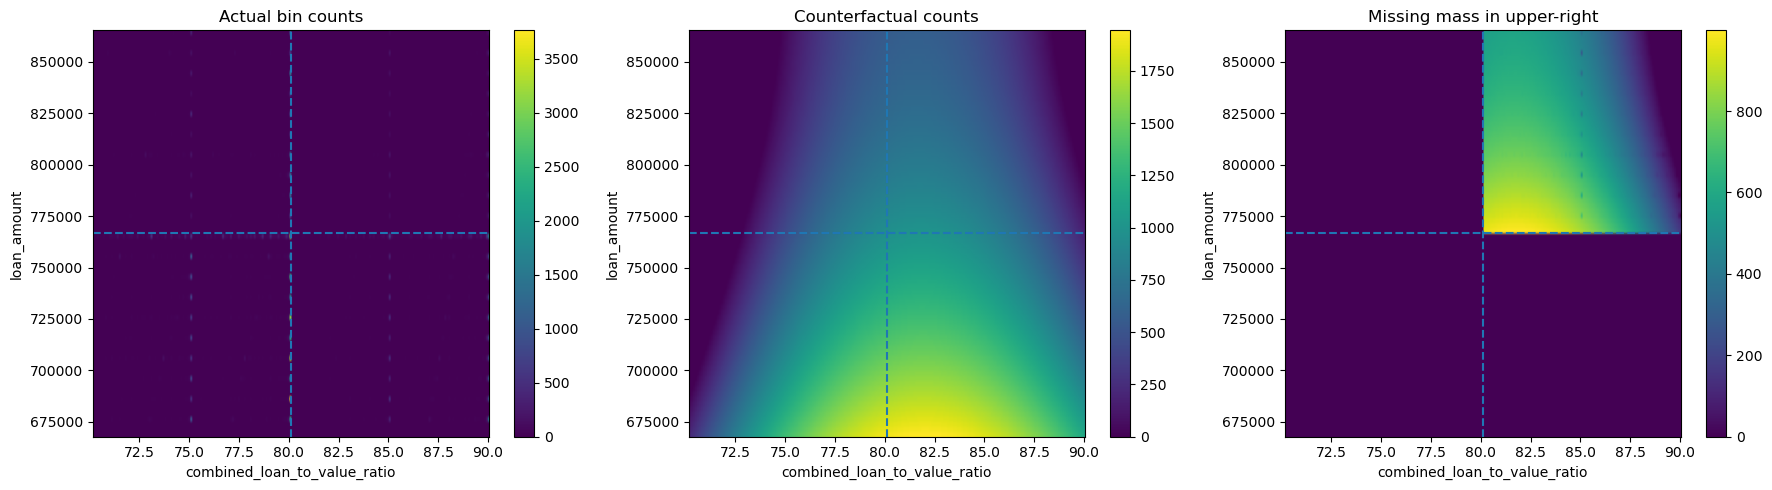

missing_mass_upper_right = 2039008.5042742435
cf_mass_upper_right      = 2043155.2280311277
actual_mass_upper_right  = 7436.0
missing_share_upper_right= 0.9979704313700726
implied_spread           = nan


In [74]:
c1 = 80.1
c2 = 766550
fit_window1=10
fit_window2=100000
res = estimate_missing_mass_two_x_and(
    df=dftest,
    x1_col="combined_loan_to_value_ratio",
    x2_col="loan_amount",
    c1=c1,
    c2=c2,
    bin_width1=0.1,
    bin_width2=2500,
    fit_window1=fit_window1,
    fit_window2=fit_window2,
    missing_width1=10,
    missing_width2=100000,
    exclude_width1=0.75,
    exclude_width2=7500,
    poly_order=2,
    elasticity=None,
    make_plot=True
)

print("missing_mass_upper_right =", res["missing_mass_upper_right"])
print("cf_mass_upper_right      =", res["cf_mass_upper_right"])
print("actual_mass_upper_right  =", res["actual_mass_upper_right"])
print("missing_share_upper_right=", res["missing_share_upper_right"])
print("implied_spread           =", res["implied_spread"])

In [76]:
import numpy as np
import pandas as pd

# Use your results
missing_share = res["missing_share_upper_right"]

# A set of k values from the literature (in decimal rate units)
# e.g. 0.01 = 1% spread
k_list = [1.6, 2.0, 2.3, 3.0, 4.0, 5.2]

# Prevent numerical errors
eps = 1e-12
survive_share = np.clip(1 - missing_share, eps, 1 - eps)

spread_rows = []
for k in k_list:
    c = -np.log(survive_share) / k   # decimal rate
    spread_rows.append({
        "k": k,
        "c_decimal": c,        # e.g. 0.015 = 1.5%
        "c_pct": c * 100,      # percentage points
        "c_bp": c * 10000      # bp
    })

spread_df = pd.DataFrame(spread_rows)

# Also store back to res
res["implied_c_table"] = spread_df
res["implied_c_baseline_k2.3"] = float(spread_df.loc[spread_df["k"] == 2.3, "c_decimal"].iloc[0])
res["implied_c_baseline_k3.0"] = float(spread_df.loc[spread_df["k"] == 3.0, "c_decimal"].iloc[0])

print(spread_df)

     k  c_decimal       c_pct          c_bp
0  1.6   3.874958  387.495750  38749.575038
1  2.0   3.099966  309.996600  30999.660030
2  2.3   2.695623  269.562261  26956.226113
3  3.0   2.066644  206.664400  20666.440020
4  4.0   1.549983  154.998300  15499.830015
5  5.2   1.192295  119.229462  11922.946166


In [45]:
grid = res["grid"]

check = grid[
    (grid["x1_mid"] >= 80.1) & (grid["x1_mid"] <= 80.75) &
    (grid["x2_mid"] >= 766550) & (grid["x2_mid"] <= 766550 + 7500)
][["x1_mid", "x2_mid", "count", "cf_count", "missing_ur"]]

print(check)
print("sum count =", check["count"].sum())
print("sum cf    =", check["cf_count"].sum())

      x1_mid    x2_mid  count     cf_count   missing_ur
1220   80.15  767800.0    0.0  1160.751928  1160.751928
1221   80.15  770300.0    0.0  1118.465158  1118.465158
1222   80.15  772800.0    0.0  1079.118843  1079.118843
1260   80.25  767800.0    0.0  1163.032571  1163.032571
1261   80.25  770300.0    0.0  1120.012366  1120.012366
1262   80.25  772800.0    0.0  1079.932616  1079.932616
1300   80.35  767800.0    0.0  1160.464446  1160.464446
1301   80.35  770300.0    0.0  1116.710806  1116.710806
1302   80.35  772800.0    0.0  1075.897621  1075.897621
1340   80.45  767800.0    0.0  1153.047553  1153.047553
1341   80.45  770300.0    0.0  1108.560479  1108.560479
1342   80.45  772800.0    0.0  1067.013859  1067.013859
1380   80.55  767800.0    0.0  1140.781893  1140.781893
1381   80.55  770300.0    0.0  1095.561383  1095.561383
1382   80.55  772800.0    0.0  1053.281328  1053.281328
1420   80.65  767800.0    0.0  1123.667464  1123.667464
1421   80.65  770300.0    0.0  1077.713520  1077

In [72]:
import numpy as np
import pandas as pd

# Set thresholds

# First create local window
local = dftest.copy()
local["combined_loan_to_value_ratio"] = pd.to_numeric(local["combined_loan_to_value_ratio"], errors="coerce")
local["loan_amount"] = pd.to_numeric(local["loan_amount"], errors="coerce")

local = local[
    local["combined_loan_to_value_ratio"].between(c1-fit_window1, c2+fit_window1) &
    local["loan_amount"].between(c2 - fit_window2, c2 + fit_window2)
].copy()

print("Local window sample size =", len(local))
print()

# -------------------------
# 1) CLTV statistics alone
# -------------------------
cltv_lt = (local["combined_loan_to_value_ratio"] < c1).sum()
cltv_eq = (local["combined_loan_to_value_ratio"] == c1).sum()
cltv_gt = (local["combined_loan_to_value_ratio"] > c1).sum()
cltv_ge = (local["combined_loan_to_value_ratio"] >= c1).sum()

print("CLTV boundary statistics:")
print(f"  < 80.1  : {cltv_lt}")
print(f"  = 80.1  : {cltv_eq}")
print(f"  > 80.1  : {cltv_gt}")
print(f"  >= 80.1 : {cltv_ge}")
print()

# -------------------------
# 2) Loan amount statistics alone
# -------------------------
amt_lt = (local["loan_amount"] < c2).sum()
amt_eq = (local["loan_amount"] == c2).sum()
amt_gt = (local["loan_amount"] > c2).sum()
amt_ge = (local["loan_amount"] >= c2).sum()

print("Loan amount boundary statistics:")
print(f"  < c2  : {amt_lt}")
print(f"  = c2  : {amt_eq}")
print(f"  > c2  : {amt_gt}")
print(f"  >= c2 : {amt_ge}")
print()

# -------------------------
# 3) Can also show proportions directly
# -------------------------
n = len(local)

print("Proportions:")
print(f"  CLTV > 80.1 share        = {cltv_gt / n:.4f}")
print(f"  CLTV >= 80.1 share       = {cltv_ge / n:.4f}")
print(f"  loan_amount > c2 share = {amt_gt / n:.4f}")
print(f"  loan_amount >= c2 share= {amt_ge / n:.4f}")

局部窗口样本数 = 149303

CLTV 边界统计:
  < 80.1  : 66337
  = 80.1  : 3
  > 80.1  : 82963
  >= 80.1 : 82966

Loan amount 边界统计:
  < c2  : 115927
  = c2  : 0
  > c2  : 33376
  >= c2 : 33376

比例:
  CLTV > 80.1 占比        = 0.5557
  CLTV >= 80.1 占比       = 0.5557
  loan_amount > c2 占比 = 0.2235
  loan_amount >= c2 占比= 0.2235


In [75]:
upper_right_box = local[
    (local["combined_loan_to_value_ratio"] > c1) &
    (local["combined_loan_to_value_ratio"] <= c1 + fit_window1) &
    (local["loan_amount"] > c2) &
    (local["loan_amount"] <= c2 + fit_window2)
]

print("Upper-right missing rectangle count =", len(upper_right_box))

右上缺失矩形人数 = 7436


In [68]:
both_cross = (
    (dftest["combined_loan_to_value_ratio"] > c1) &
    (dftest["loan_amount"] > c2)
)
cross_c1 = (dftest["combined_loan_to_value_ratio"] > c1).sum()
cross_c2 = (dftest["loan_amount"] > c2).sum()
print("Count exceeding CLTV 80.1 =", cross_c1)
print("Count exceeding loan amount threshold =", cross_c2)
print("Count exceeding both thresholds =", both_cross.sum())

超过 CLTV 80.1 的人数 = 1954711
超过 loan amount 阈值的人数 = 214129
同时超过两个阈值的人数 = 50933


In [57]:
dftest["applicant_age"].head()

0    55-64
1    55-64
2    45-54
3    65-74
4    55-64
Name: applicant_age, dtype: object

In [58]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


c2 = 766550      # 2024 conforming loan limit
c1 = 80.1        # PMI threshold
band_loan = 50000   # Start with ±50k; change to 30000/20000 for robustness checks


work = dftest.copy()


candidate_cols = [
    "interest_rate",
    "loan_amount",
    "combined_loan_to_value_ratio",
    "income",
    "debt_to_income_ratio",
    "property_value",
    "loan_term",
    "applicant_age",
    "state_code"
]

keep_cols = [c for c in candidate_cols if c in work.columns]
work = work[keep_cols].copy()

# =========================================================
# 3. Clean numeric variables
#    Note: HMDA often contains "Exempt", "NA", empty strings, etc.
# =========================================================
num_cols = [
    "interest_rate",
    "loan_amount",
    "combined_loan_to_value_ratio",
    "income",
    "debt_to_income_ratio",
    "property_value",
    "loan_term"
]

for col in num_cols:
    if col in work.columns:
        work[col] = pd.to_numeric(work[col], errors="coerce")

# Categorical variable processing
if "state_code" in work.columns:
    work["state_code"] = work["state_code"].astype(str).replace({"nan": np.nan})

if "applicant_age" in work.columns:
    work["applicant_age"] = work["applicant_age"].astype(str).replace({"nan": np.nan})

# =========================================================
# 4. Local window: only around the conforming loan limit
# =========================================================
work = work.dropna(subset=["interest_rate", "loan_amount", "combined_loan_to_value_ratio"]).copy()

local = work[
    work["loan_amount"].between(c2 - band_loan, c2 + band_loan)
].copy()

# =========================================================
# 5. Construct RD variables
# =========================================================
local["jumbo"] = (local["loan_amount"] > c2).astype(int)
local["dist_k"] = (local["loan_amount"] - c2) / 1000.0   # unit: $1000
local["pmi_gt80"] = (local["combined_loan_to_value_ratio"] > c1).astype(int)

# Log-transform income / property_value (positive values only)
if "income" in local.columns:
    local.loc[local["income"] <= 0, "income"] = np.nan
    local["log_income"] = np.log(local["income"])

if "property_value" in local.columns:
    local.loc[local["property_value"] <= 0, "property_value"] = np.nan
    local["log_property_value"] = np.log(local["property_value"])

# Restrict DTI if clearly anomalous, as needed
if "debt_to_income_ratio" in local.columns:
    # Optional: remove extreme outliers
    local.loc[(local["debt_to_income_ratio"] < 0) | (local["debt_to_income_ratio"] > 100), "debt_to_income_ratio"] = np.nan

# =========================================================
# 6. Check jumbo share in local sample
# =========================================================
print("=" * 70)
print("Local sample size before model-specific dropna =", len(local))
print("Jumbo counts:")
print(local["jumbo"].value_counts(dropna=False))
print("Jumbo share =", local["jumbo"].mean())
print("=" * 70)

# =========================================================
# 7. Helper function: fit model and print results
# =========================================================
def run_model(data, formula, model_name):
    use = data.copy()
    # Check key variable missingness before statsmodels drops rows by formula
    print(f"\n{'='*70}")
    print(f"{model_name}")
    print("Formula:", formula)

    # Try to extract common variables from formula for missingness check
    check_vars = [
        "interest_rate", "jumbo", "dist_k", "pmi_gt80",
        "log_income", "log_property_value", "debt_to_income_ratio",
        "loan_term", "applicant_age", "state_code"
    ]
    check_vars = [v for v in check_vars if v in use.columns]
    if check_vars:
        print("\nMissing counts in available columns:")
        print(use[check_vars].isna().sum().sort_values(ascending=False))

    mod = smf.ols(formula, data=use).fit(cov_type="HC1")

    print("\nUsable rows in fitted model =", int(mod.nobs))
    print(mod.summary())

    if "jumbo" in mod.params.index:
        tau = mod.params["jumbo"]
        se = mod.bse["jumbo"]
        print("\nJumbo coefficient =", tau, "percentage points")
        print("Robust SE =", se)
        print("= ", tau * 100, "bps")

    return mod

# =========================================================
# 8. Model 1: Minimal model
# =========================================================
formula1 = "interest_rate ~ jumbo + dist_k + jumbo:dist_k"
mod1 = run_model(local, formula1, "Model 1: Minimal local RD")

# =========================================================
# 9. Model 2: + borrower quality controls + PMI
# =========================================================
rhs2 = ["jumbo", "dist_k", "jumbo:dist_k", "pmi_gt80"]

if "log_income" in local.columns:
    rhs2.append("log_income")
if "log_property_value" in local.columns:
    rhs2.append("log_property_value")
if "debt_to_income_ratio" in local.columns:
    rhs2.append("debt_to_income_ratio")
if "loan_term" in local.columns:
    rhs2.append("loan_term")
if "applicant_age_above_62" in local.columns:
    rhs2.append("C(applicant_age_above_62)")

formula2 = "interest_rate ~ " + " + ".join(rhs2)
mod2 = run_model(local, formula2, "Model 2: + PMI + borrower controls")

# =========================================================
# 10. Model 3: + state fixed effects
# =========================================================
rhs3 = rhs2.copy()
if "state_code" in local.columns:
    rhs3.append("C(state_code)")

formula3 = "interest_rate ~ " + " + ".join(rhs3)
mod3 = run_model(local, formula3, "Model 3: + state fixed effects")

# =========================================================
# 11. Select final model (prefer mod3, fall back to mod2)
# =========================================================
final_mod = mod3 if "jumbo" in mod3.params.index else mod2

tau_pp = final_mod.params["jumbo"]   # percentage points
tau_se = final_mod.bse["jumbo"]

print("\n" + "=" * 70)
print("FINAL CHOSEN MODEL: Jumbo spread")
print("tau_pp =", tau_pp, "percentage points")
print("tau_bp =", tau_pp * 100, "bps")
print("tau_se =", tau_se)
print("=" * 70)

# =========================================================
# 12. Monthly payment change for a representative loan
#     Interest rate is in percentage units, e.g. 6.75
# =========================================================
def pmt(principal, annual_rate_percent, n_months):
    rm = annual_rate_percent / 100 / 12
    if abs(rm) < 1e-12:
        return principal / n_months
    return principal * (rm * (1 + rm)**n_months) / ((1 + rm)**n_months - 1)

# Use final model's usable sample for the representative loan
# For simplicity, use mean of non-missing core variables in local
rep = local.dropna(subset=["interest_rate", "loan_amount", "loan_term"]).copy()

L_bar = rep["loan_amount"].mean()
r_bar = rep["interest_rate"].mean()
n_bar = rep["loan_term"].mean()

monthly_base = pmt(L_bar, r_bar, n_bar)
monthly_jumbo = pmt(L_bar, r_bar + tau_pp, n_bar)
delta_monthly_jumbo = monthly_jumbo - monthly_base

print("\nRepresentative loan:")
print("L_bar =", L_bar)
print("r_bar =", r_bar)
print("n_bar =", n_bar)
print("Monthly payment change from jumbo spread =", delta_monthly_jumbo)

# =========================================================
# 13. Adding PMI costs
#     Assume an annualized PMI rate, e.g. 0.6%
# =========================================================
pmi_rate_pp = 0.6   # percentage points/year; change to 0.4 / 0.8 / 1.0 for sensitivity analysis
delta_monthly_pmi = (pmi_rate_pp / 100) * L_bar / 12

delta_monthly_total = delta_monthly_jumbo + delta_monthly_pmi

print("\nAssumed PMI equivalent rate =", pmi_rate_pp, "percentage points/year")
print("Monthly PMI cost =", delta_monthly_pmi)
print("Total monthly extra cost (jumbo + PMI) =", delta_monthly_total)

# =========================================================
# 14. Multiply by missing mass
# =========================================================
M = 26182   # your own missing mass

agg_monthly_loss = M * delta_monthly_total
agg_annual_loss = 12 * agg_monthly_loss

print("\nMissing mass M =", M)
print("Aggregate monthly loss =", agg_monthly_loss)
print("Aggregate annual loss =", agg_annual_loss)

Local sample size before model-specific dropna = 110872
Jumbo counts:
jumbo
0    84665
1    26207
Name: count, dtype: int64
Jumbo share = 0.23637167183779492

Model 1: Minimal local RD
Formula: interest_rate ~ jumbo + dist_k + jumbo:dist_k

Missing counts in available columns:
log_income            434
interest_rate           0
jumbo                   0
dist_k                  0
pmi_gt80                0
log_property_value      0
loan_term               0
applicant_age           0
state_code              0
dtype: int64

Usable rows in fitted model = 110872
                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     53.89
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           8.51e-35
Time:                        15:51:50   Lo

In [ ]:
X_col = [
    "income",
    "dti_num",
    "applicant_age",
    "co_applicant_age",
    "derived_ethnicity",
    "derived_race",
    "derived_sex",
    "property_value",
    "derived_loan_product_type",
    "derived_dwelling_category",
    "occupancy_type",
    "construction_method",
    "total_units",
    "loan_type",
    "loan_purpose",
    "lien_status",
    "business_or_commercial_purpose",
    "open_end_line_of_credit",
    "hoepa_status",
    "reverse_mortgage",
    "negative_amortization",
    "balloon_payment",
    "interest_only_payment",
    "other_nonamortizing_features",
    "manufactured_home_land_property_interest",
    "manufactured_home_secured_property_type",
    "initially_payable_to_institution",
    "activity_year",
    "derived_msa_md",
    "county_code",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "tract_owner_occupied_units",
    "tract_one_to_four_family_homes",
    "tract_median_age_of_housing_units"
]